# Customer Churn Prediction — Google Colab

## Supervised Learning theo hướng kinh doanh (Business-Oriented Learning Monitoring)

Notebook của projects này tự tải dữ liệu Telco Customer Churn từ Kaggle, chạy EDA, huấn luyện và so sánh Logistic Regression, Decision Tree, Random Forest; sau đó chọn ngưỡng theo F2 để lập danh sách khách hàng ưu tiên giữ chân.

Chạy các cell từ trên xuống. Kết quả được lưu trong thư mục `outputs/`.

### Thiết lập môi trường và tải dữ liệu

Cell này cần kết nối Internet để tải bộ dữ liệu công khai từ Kaggle. Không cần upload thêm file nào.

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl

from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
dataset_path = data_dir / 'Telco_customer_churn.xlsx'

if not dataset_path.exists():
    archive_path = Path('telco_customer_churn.zip')
    dataset_url = 'https://www.kaggle.com/api/v1/datasets/download/ylchang/telco-customer-churn-1113'
    print('Đang tải dữ liệu từ Kaggle...')
    urlretrieve(dataset_url, archive_path)
    with ZipFile(archive_path) as archive:
        archive.extractall(data_dir)
    archive_path.unlink()

assert dataset_path.exists(), 'Không tải được file dữ liệu.'
print(f'Sẵn sàng: {dataset_path}')

Đang tải dữ liệu từ Kaggle...
Sẵn sàng: data/Telco_customer_churn.xlsx


### Chạy pipeline supervised learning

Các cột gây rò rỉ nhãn (`Churn Value`, `Churn Score`, `Churn Reason`) được loại bỏ trước khi huấn luyện. Tập test chỉ dùng một lần ở bước đánh giá cuối.

In [4]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")

RANDOM_STATE = 42
DATA_PATH = Path("data/Telco_customer_churn.xlsx")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_figure(filename):
    """Save the current matplotlib figure into the project output directory."""
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.close()


def calculate_metrics(y_true, probabilities, threshold=0.50):
    """Return classification metrics, treating churn (1) as the positive class."""
    predictions = (probabilities >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities),
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision (churn)": precision_score(y_true, predictions, zero_division=0),
        "Recall (churn)": recall_score(y_true, predictions, zero_division=0),
        "F1 (churn)": f1_score(y_true, predictions, zero_division=0),
        "F2 (churn)": fbeta_score(y_true, predictions, beta=2, zero_division=0),
    }


def main():
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Không tìm thấy {DATA_PATH}. Hãy tải bộ dữ liệu Kaggle vào thư mục data."
        )

    # 1. Load and inspect data
    df = pd.read_excel(DATA_PATH)
    print(f"Dữ liệu: {df.shape[0]:,} khách hàng × {df.shape[1]} biến")

    overview = pd.DataFrame(
        {
            "data_type": df.dtypes.astype(str),
            "missing_count": df.isna().sum(),
            "missing_rate_pct": (df.isna().mean() * 100).round(2),
            "n_unique": df.nunique(),
        }
    )
    overview.to_csv(OUTPUT_DIR / "data_overview.csv", encoding="utf-8-sig")

    target_rate = (
        df["Churn Label"]
        .value_counts(dropna=False)
        .rename_axis("Churn Label")
        .reset_index(name="customer_count")
    )
    target_rate["rate_pct"] = (target_rate["customer_count"] / len(df) * 100).round(2)
    target_rate.to_csv(OUTPUT_DIR / "target_distribution.csv", index=False, encoding="utf-8-sig")
    print("\nPhân bố churn:")
    print(target_rate.to_string(index=False))

    # 2. Exploratory business analysis
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    for ax, feature, title in zip(
        axes,
        ["Contract", "Internet Service", "Payment Method"],
        [
            "Tỷ lệ churn theo loại hợp đồng",
            "Tỷ lệ churn theo dịch vụ Internet",
            "Tỷ lệ churn theo phương thức thanh toán",
        ],
    ):
        churn_rate = (
            pd.crosstab(df[feature], df["Churn Label"], normalize="index")
            .mul(100)["Yes"]
            .sort_values(ascending=False)
        )
        sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=ax, color="#d95f02")
        ax.set(title=title, xlabel=feature, ylabel="Tỷ lệ churn (%)")
        ax.tick_params(axis="x", rotation=32)
        for position, value in enumerate(churn_rate.values):
            ax.text(position, value + 0.5, f"{value:.1f}%", ha="center", fontsize=9)
    save_figure("01_churn_rate_by_business_feature.png")

    plot_df = df.copy()
    plot_df["Churn Label"] = plot_df["Churn Label"].map({"No": "Ở lại", "Yes": "Rời bỏ"})
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(
        data=plot_df, x="Churn Label", y="Tenure Months",
        order=["Ở lại", "Rời bỏ"], ax=axes[0]
    )
    axes[0].set(title="Thâm niên theo trạng thái churn", xlabel="", ylabel="Số tháng gắn bó")
    sns.boxplot(
        data=plot_df, x="Churn Label", y="Monthly Charges",
        order=["Ở lại", "Rời bỏ"], ax=axes[1]
    )
    axes[1].set(title="Chi phí hằng tháng theo trạng thái churn", xlabel="", ylabel="USD")
    save_figure("02_tenure_and_monthly_charges.png")

    # 3. Prevent data leakage
    target = "Churn Label"
    excluded_columns = [
        "CustomerID",       # identifier
        "Count", "Country", "State",  # constants
        "Lat Long", "Latitude", "Longitude",  # duplicate/overly granular location
        "Churn Value",      # direct numeric encoding of target
        "Churn Score",      # prediction generated by another model
        "Churn Reason",     # known only after the customer churns
    ]
    X = df.drop(columns=excluded_columns + [target]).copy()
    y = df[target].map({"No": 0, "Yes": 1})

    # Convert 'Total Charges' to numeric, coercing errors to NaN
    # This column often contains ' ' which causes it to be read as object type
    X["Total Charges"] = pd.to_numeric(X["Total Charges"], errors="coerce")

    print(f"\nSố đặc trưng sau lọc leakage: {X.shape[1]}")
    print("Đặc trưng số:", X.select_dtypes(include=np.number).columns.tolist())
    print("Đặc trưng phân loại:", X.select_dtypes(exclude=np.number).columns.tolist())

    # A stratified 60/20/20 split: validation selects threshold; test is untouched.
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25,
        stratify=y_train_val, random_state=RANDOM_STATE
    )
    split_summary = pd.DataFrame(
        [
            ["Train", len(y_train), y_train.mean()],
            ["Validation", len(y_val), y_val.mean()],
            ["Test", len(y_test), y_test.mean()],
        ],
        columns=["split", "customers", "churn_rate"],
    )
    split_summary.to_csv(OUTPUT_DIR / "split_summary.csv", index=False, encoding="utf-8-sig")
    print("\nChia dữ liệu:")
    print(split_summary.assign(churn_rate=lambda d: d["churn_rate"].map("{:.2%}".format)).to_string(index=False))

    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )

    # 4. Model comparison on validation data
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=6, min_samples_leaf=20,
            class_weight="balanced", random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=400, max_depth=12, min_samples_leaf=5,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        ),
    }

    pipelines = {}
    validation_rows = []
    for name, estimator in models.items():
        pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])
        pipeline.fit(X_train, y_train)
        probabilities = pipeline.predict_proba(X_val)[:, 1]
        validation_rows.append({"model": name, **calculate_metrics(y_val, probabilities)})
        pipelines[name] = pipeline

    validation_results = (
        pd.DataFrame(validation_rows)
        .sort_values(["PR-AUC", "ROC-AUC"], ascending=False)
        .reset_index(drop=True)
    )
    validation_results.to_csv(
        OUTPUT_DIR / "validation_model_comparison.csv", index=False, encoding="utf-8-sig"
    )
    print("\nSo sánh mô hình trên validation:")
    print(validation_results.round(3).to_string(index=False))

    chart_results = validation_results.melt(
        id_vars="model", value_vars=["ROC-AUC", "PR-AUC", "Recall (churn)", "F1 (churn)"],
        var_name="metric", value_name="score"
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(data=chart_results, x="metric", y="score", hue="model")
    plt.ylim(0, 1)
    plt.title("So sánh hiệu năng validation")
    plt.xlabel("")
    plt.ylabel("Score")
    save_figure("03_validation_model_comparison.png")

    # 5. Threshold selection: F2 emphasizes recall for churn intervention.
    best_model_name = validation_results.loc[0, "model"]
    best_validation_model = pipelines[best_model_name]
    validation_probabilities = best_validation_model.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.01)
    threshold_table = pd.DataFrame(
        {
            "threshold": thresholds,
            "precision": [
                precision_score(y_val, validation_probabilities >= threshold, zero_division=0)
                for threshold in thresholds
            ],
            "recall": [
                recall_score(y_val, validation_probabilities >= threshold, zero_division=0)
                for threshold in thresholds
            ],
            "f1": [
                f1_score(y_val, validation_probabilities >= threshold, zero_division=0)
                for threshold in thresholds
            ],
            "f2": [
                fbeta_score(y_val, validation_probabilities >= threshold, beta=2, zero_division=0)
                for threshold in thresholds
            ],
        }
    )
    best_threshold = threshold_table.loc[threshold_table["f2"].idxmax(), "threshold"]
    threshold_table.to_csv(OUTPUT_DIR / "threshold_selection.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(10, 5))
    for metric in ["precision", "recall", "f1", "f2"]:
        plt.plot(threshold_table["threshold"], threshold_table[metric], label=metric.upper())
    plt.axvline(best_threshold, color="black", linestyle="--", label=f"Ngưỡng chọn: {best_threshold:.2f}")
    plt.title(f"Chọn ngưỡng cho {best_model_name} trên validation")
    plt.xlabel("Ngưỡng xác suất churn")
    plt.ylabel("Score")
    plt.legend()
    save_figure("04_threshold_selection.png")
    print(f"\nMô hình chọn: {best_model_name}; ngưỡng F2 tối ưu: {best_threshold:.2f}")

    # 6. A single final evaluation on unseen test data.
    final_pipeline = Pipeline(
        steps=[("preprocessor", preprocessor), ("model", models[best_model_name])]
    )
    final_pipeline.fit(X_train_val, y_train_val)
    test_probabilities = final_pipeline.predict_proba(X_test)[:, 1]
    test_predictions = (test_probabilities >= best_threshold).astype(int)
    test_metrics = pd.DataFrame(
        [calculate_metrics(y_test, test_probabilities, best_threshold)],
        index=[best_model_name],
    )
    test_metrics.to_csv(OUTPUT_DIR / "test_metrics.csv", encoding="utf-8-sig")
    print("\nKết quả cuối cùng trên test set:")
    print(test_metrics.round(3).to_string())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, test_predictions),
        display_labels=["Ở lại", "Rời bỏ"],
    ).plot(ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title("Confusion matrix")
    RocCurveDisplay.from_predictions(y_test, test_probabilities, ax=axes[1])
    axes[1].set_title("ROC curve")
    PrecisionRecallDisplay.from_predictions(y_test, test_probabilities, ax=axes[2])
    axes[2].set_title("Precision-Recall curve")
    save_figure("05_test_evaluation.png")

    report = classification_report(
        y_test, test_predictions, target_names=["Ở lại", "Rời bỏ"], output_dict=True
    )
    pd.DataFrame(report).transpose().to_csv(
        OUTPUT_DIR / "classification_report.csv", encoding="utf-8-sig"
    )

    # 7. Business action list. Real labels are deliberately not exported.
    retention_list = X_test.copy()
    retention_list.insert(0, "CustomerID", df.loc[X_test.index, "CustomerID"])
    retention_list["Churn_probability"] = test_probabilities
    retention_list["Action"] = np.where(
        test_predictions == 1, "Ưu tiên liên hệ giữ chân", "Theo dõi"
    )
    priority_columns = [
        "CustomerID", "Churn_probability", "Action", "Contract",
        "Internet Service", "Tenure Months", "Monthly Charges", "Payment Method",
    ]
    retention_list[priority_columns].sort_values(
        "Churn_probability", ascending=False
    ).to_csv(OUTPUT_DIR / "retention_priority_list.csv", index=False, encoding="utf-8-sig")

    print("\nTop 10 khách hàng cần ưu tiên giữ chân:")
    print(
        retention_list[priority_columns]
        .sort_values("Churn_probability", ascending=False)
        .head(10)
        .to_string(index=False)
    )
    print(f"\nĐã lưu báo cáo, biểu đồ và danh sách hành động vào: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()

Dữ liệu: 7,043 khách hàng × 33 biến

Phân bố churn:
Churn Label  customer_count  rate_pct
         No            5174     73.46
        Yes            1869     26.54

Số đặc trưng sau lọc leakage: 22
Đặc trưng số: ['Zip Code', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
Đặc trưng phân loại: ['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Chia dữ liệu:
     split  customers churn_rate
     Train       4225     26.53%
Validation       1409     26.54%
      Test       1409     26.54%

So sánh mô hình trên validation:
              model  ROC-AUC  PR-AUC  Accuracy  Precision (churn)  Recall (churn)  F1 (churn)  F2 (churn)
      Random Forest    0.842   0.639     0.744              0.511           0.802       0.624       0.720
Logistic Regression  

### Xem kết quả

PR-AUC, recall và F1/F2 của lớp churn được ưu tiên thay vì chỉ dùng accuracy.

,model,ROC-AUC,PR-AUC,Accuracy,Precision (churn),Recall (churn),F1 (churn),F2 (churn)
0,Random Forest,0.841840,0.639214,0.743790,0.511073,0.802139,0.624350,0.720115
1,Logistic Regression,0.840678,0.637792,0.757984,0.531309,0.748663,0.621532,0.692042
2,Decision Tree,0.840642,0.615716,0.757275,0.528470,0.794118,0.634615,0.721574


,ROC-AUC,PR-AUC,Accuracy,Precision (churn),Recall (churn),F1 (churn),F2 (churn)
Random Forest,0.836325,0.6345,0.626686,0.408434,0.906417,0.563123,0.728719


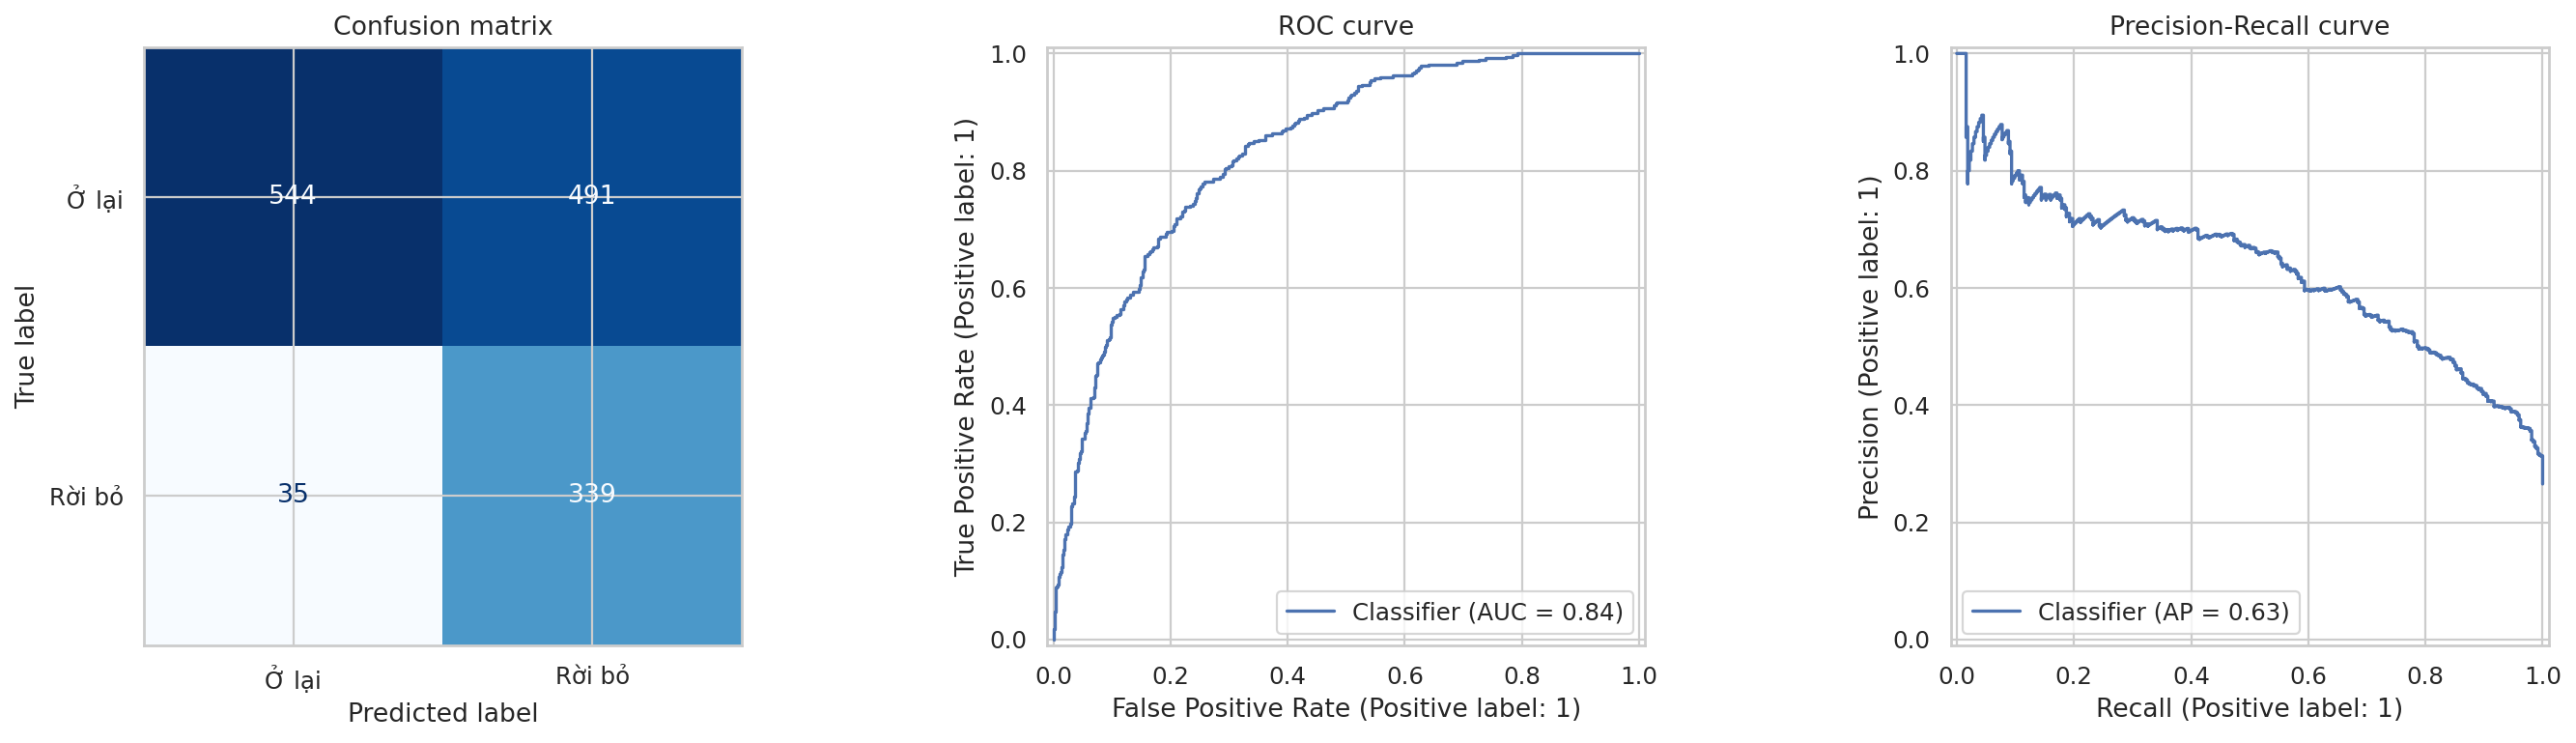

,CustomerID,Churn_probability,Action,Contract,Internet Service,Tenure Months,Monthly Charges,Payment Method
0,1069-XAIEM,77.2%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,1,85.050000,Electronic check
1,1143-NMNQJ,76.6%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,2,85.700000,Electronic check
2,4750-ZRXIU,76.5%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,4,84.600000,Electronic check
3,2609-IAICY,76.3%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,1,77.150000,Electronic check
4,9248-OJYKK,76.3%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,1,76.450000,Electronic check
5,8083-YTZES,76.2%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,4,74.350000,Electronic check
6,5542-TBBWB,76.1%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,1,69.900000,Electronic check
7,3716-BDVDB,76.1%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,1,69.100000,Electronic check
8,2545-EBUPK,76.0%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,2,84.050000,Electronic check
9,7409-KIUTL,76.0%,Ưu tiên liên hệ giữ chân,Month-to-month,Fiber optic,1,71.000000,Electronic check


In [5]:
from IPython.display import Image, display

display(pd.read_csv('outputs/validation_model_comparison.csv'))
display(pd.read_csv('outputs/test_metrics.csv', index_col=0))
display(Image(filename='outputs/05_test_evaluation.png'))

priority_list = pd.read_csv('outputs/retention_priority_list.csv')
priority_list.head(20).style.format({'Churn_probability': '{:.1%}'})

### Tải kết quả về máy

In [6]:
from google.colab import files
!zip -rq customer_churn_outputs.zip outputs
files.download('customer_churn_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>